In [2]:
# =================== IMPORTS ===================
import os
import numpy as np
import random
import tensorflow as tf
import time
from tensorflow.keras import layers, models, callbacks, backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy
from shutil import rmtree, copyfile
from tqdm import tqdm
from tensorflow.keras import mixed_precision

# =================== CUSTOM LAYERS ===================
@tf.keras.utils.register_keras_serializable()
class MeanChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)

@tf.keras.utils.register_keras_serializable()
class MaxChannel(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)

# =================== ENABLE MIXED PRECISION ===================
mixed_precision.set_global_policy('mixed_float16')

# =================== CONSTANTS ===================
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 60
train_ratio, val_ratio = 0.7, 0.15

# =================== DIRECTORIES ===================
dataset_dir = '/kaggle/input/colon-augmented-custom/colon_augmented_png_v9'
base_dir = '/kaggle/working/colon_split'

# =================== CLEAN EXISTING SPLITS ===================
if os.path.exists(base_dir):
    for folder in os.listdir(base_dir):
        rmtree(os.path.join(base_dir, folder))

# =================== DATA SPLIT ===================
splits = ['train', 'val', 'test']
class_names = os.listdir(dataset_dir)

for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(base_dir, split, class_name), exist_ok=True)

for class_name in class_names:
    image_list = os.listdir(os.path.join(dataset_dir, class_name))
    random.shuffle(image_list)

    n_total = len(image_list)
    n_train = int(train_ratio * n_total)
    n_val = int(val_ratio * n_total)

    train_files = image_list[:n_train]
    val_files = image_list[n_train:n_train + n_val]
    test_files = image_list[n_train + n_val:]

    for split, split_files in zip(['train', 'val', 'test'], [train_files, val_files, test_files]):
        for img in tqdm(split_files, desc=f'{class_name} - {split}'):
            src = os.path.join(dataset_dir, class_name, img)
            dst = os.path.join(base_dir, split, class_name, img)
            copyfile(src, dst)

# =================== DATA GENERATORS ===================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)
val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(base_dir, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    os.path.join(base_dir, 'test'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# =================== MODEL BUILDING ===================
def cbam_block(input_feature, ratio=8):
    channel = input_feature.shape[-1]

    avg_pool = layers.GlobalAveragePooling2D()(input_feature)
    max_pool = layers.GlobalMaxPooling2D()(input_feature)

    shared_dense_one = layers.Dense(channel // ratio, activation='relu')
    shared_dense_two = layers.Dense(channel)

    mlp_avg = shared_dense_two(shared_dense_one(avg_pool))
    mlp_max = shared_dense_two(shared_dense_one(max_pool))

    channel_attention = layers.Add()([mlp_avg, mlp_max])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)

    x = layers.Multiply()([input_feature, channel_attention])

    avg_pool_spatial = MeanChannel()(x)
    max_pool_spatial = MaxChannel()(x)
    concat = layers.Concatenate(axis=-1)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)

    refined_feature = layers.Multiply()([x, spatial_attention])
    return refined_feature

def build_model():
    base_model = tf.keras.applications.EfficientNetB0(
        include_top=False, input_shape=(224, 224, 3), weights='imagenet'
    )
    base_model.trainable = True

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=True)
    x = cbam_block(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

    model = tf.keras.Model(inputs, outputs)
    return model

model = build_model()

# =================== OPTIMIZER & LOSS ===================
lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=1.5e-4,
    decay_steps=1000,
    alpha=1e-6
)
optimizer = AdamW(learning_rate=lr_schedule, weight_decay=1e-5)
loss_fn = CategoricalCrossentropy(label_smoothing=0.1)

model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy'])

# =================== PARAMETER COUNT ===================
trainable_params = np.sum([K.count_params(w) for w in model.trainable_weights])
non_trainable_params = np.sum([K.count_params(w) for w in model.non_trainable_weights])
total_params = trainable_params + non_trainable_params

print(f"\n📊 Model Parameter Counts:")
print(f"  Total: {total_params:,}")
print(f"  Trainable: {trainable_params:,}")
print(f"  Non-trainable: {non_trainable_params:,}\n")

# =================== CALLBACKS ===================
checkpoint_cb = callbacks.ModelCheckpoint(
    'carenet.keras', monitor='val_accuracy', save_best_only=True, verbose=1
)
earlystop_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True
)

# =================== TRAINING WITH TIMING ===================
start_time = time.time()

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[checkpoint_cb, earlystop_cb],
    verbose=1
)

end_time = time.time()
total_training_time = end_time - start_time
avg_epoch_time = total_training_time / len(history.epoch)

print(f"\n⏱️ Total Training Time: {total_training_time:.2f} seconds")
print(f"⏱️ Average Time per Epoch: {avg_epoch_time:.2f} seconds")

# =================== EVALUATION ===================
model.load_weights("carenet.keras")
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")

1_ulcerative_colitis - test: 100%|██████████| 225/225 [00:00<00:00, 292.49it/s]


Found 4200 images belonging to 4 classes.
Found 900 images belonging to 4 classes.
Found 900 images belonging to 4 classes.

📊 Model Parameter Counts:
  Total: 5,118,634.0
  Trainable: 5,076,611
  Non-trainable: 42,023.0

Epoch 1/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.6156 - loss: 1.0483
Epoch 1: val_accuracy improved from -inf to 0.27000, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 179s 540ms/step - accuracy: 0.6168 - loss: 1.0464 - val_accuracy: 0.2700 - val_loss: 1.3920
Epoch 2/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.9351 - loss: 0.4934
Epoch 2: val_accuracy improved from 0.27000 to 0.30111, saving model to carenet.keras
132/132 ━━━━━━━━━━━━━━━━━━━━ 14s 106ms/step - accuracy: 0.9352 - loss: 0.4933 - val_accuracy: 0.3011 - val_loss: 1.3662
Epoch 3/60
132/132 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.9736 - loss: 0.4273
Epoch 3: val_accuracy improved from 0.30111 to 0.63000, saving model to carenet.keras
132/132 ━━━━━━━━━━━━

29/29 ━━━━━━━━━━━━━━━━━━━━ 19s 340ms/step


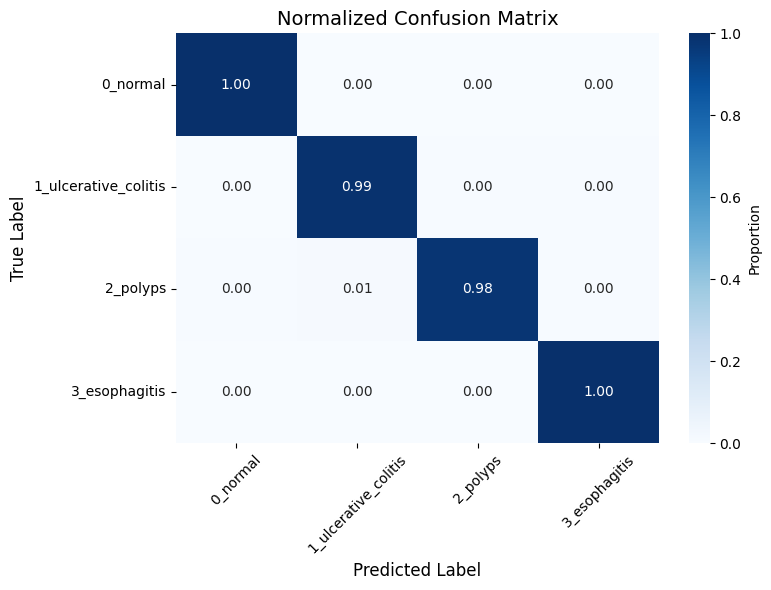

Classification Report:
                      precision    recall  f1-score   support

            0_normal       1.00      1.00      1.00       225
1_ulcerative_colitis       0.99      0.99      0.99       225
            2_polyps       1.00      0.98      0.99       225
       3_esophagitis       0.99      1.00      1.00       225

            accuracy                           0.99       900
           macro avg       0.99      0.99      0.99       900
        weighted avg       0.99      0.99      0.99       900



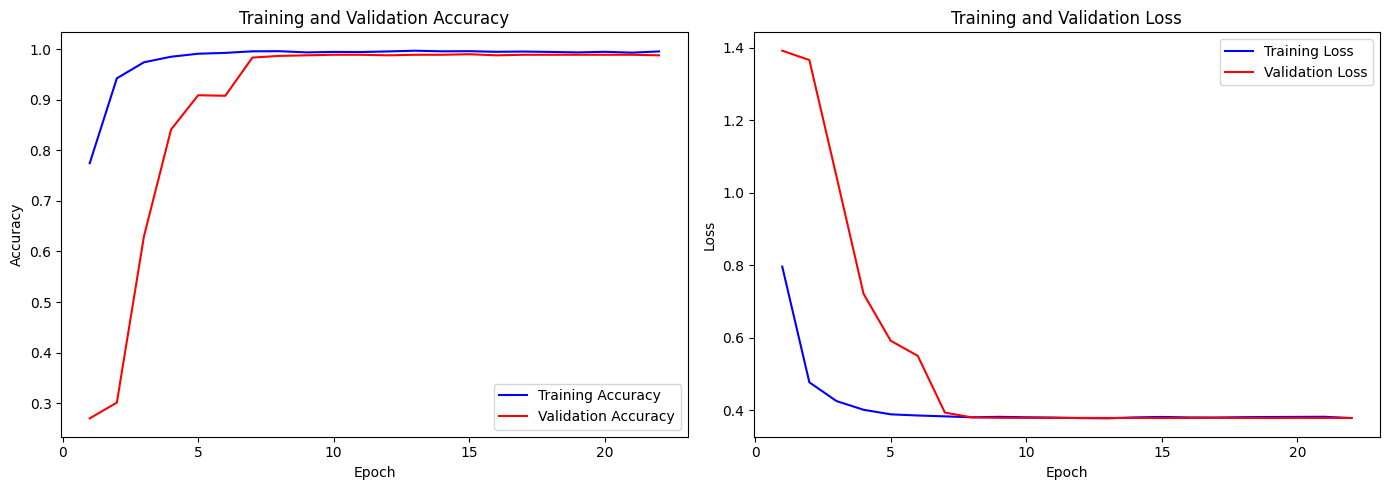

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# =================== PREDICTIONS ===================
y_true = test_generator.classes
y_pred_probs = model.predict(test_generator, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)

# =================== CLASS LABELS ===================
class_labels = list(test_generator.class_indices.keys())

# =================== CONFUSION MATRIX ===================
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]  # row-wise normalization

plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=class_labels, yticklabels=class_labels,
            cbar_kws={'label': 'Proportion'})

plt.title("Normalized Confusion Matrix", fontsize=14)
plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("True Label", fontsize=12)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# =================== CLASSIFICATION REPORT ===================
print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

# =================== TRAINING HISTORY CURVES ===================
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b-', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b-', label='Training Loss')
    plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)